#       Aerofit Case Study: Descriptive Statistics & Probability

# Business Problem and Objective:
The market research team at AeroFit wants to identify the characteristics of the target audience for each type of treadmill offered by the company, to provide a better recommendation of the treadmills to the new customers. The team decides to investigate whether there are differences across the product with respect to customer characteristics.

### Goal:
Perform descriptive analytics to create a customer profile for each AeroFit treadmill product by developing appropriate tables and charts.
For each AeroFit treadmill product, construct two-way contingency tables and compute all conditional and marginal probabilities along with their insights/impact on the business.



# Colab Notebook link:
https://colab.research.google.com/drive/1lS3uPA4UBe2g84NK83vLt4Rwwzq1aJs7#scrollTo=QNG11CWUmTOx

# Import required Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Basic Analysis : Data Overview

In [ ]:
df = pd.read_csv("aerofit_treadmill.csv")

In [ ]:
df_raw = df.copy()   # backup

In [ ]:
# Data Exploration

print("First 10 rows:")
display(df.head(10))

print("\nData types & non-null counts:")
print(df.info())

print("\nBasic Numerical summary:")
display(df.describe().transpose())

print("\nAll-columns summary:")
display(df.describe(include='all').transpose())



First 10 rows:


,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47
5,KP281,20,Female,14,Partnered,3,3,32973,66
6,KP281,21,Female,14,Partnered,3,3,35247,75
7,KP281,21,Male,13,Single,3,3,32973,85
8,KP281,21,Male,15,Single,5,4,35247,141
9,KP281,21,Female,15,Partnered,2,3,37521,85



Data types & non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB
None

Basic Numerical summary:


,count,mean,std,min,25%,50%,75%,max
Age,180.0,28.788889,6.943498,18.0,24.00,26.0,33.00,50.0
Education,180.0,15.572222,1.617055,12.0,14.00,16.0,16.00,21.0
Usage,180.0,3.455556,1.084797,2.0,3.00,3.0,4.00,7.0
Fitness,180.0,3.311111,0.958869,1.0,3.00,3.0,4.00,5.0
Income,180.0,53719.577778,16506.684226,29562.0,44058.75,50596.5,58668.00,104581.0
Miles,180.0,103.194444,51.863605,21.0,66.00,94.0,114.75,360.0



All-columns summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product,180,3,KP281,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,180.0,NaN,NaN,NaN,28.788889,6.943498,18.0,24.0,26.0,33.0,50.0
Gender,180,2,Male,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,180.0,NaN,NaN,NaN,15.572222,1.617055,12.0,14.0,16.0,16.0,21.0
MaritalStatus,180,2,Partnered,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Usage,180.0,NaN,NaN,NaN,3.455556,1.084797,2.0,3.0,3.0,4.0,7.0
Fitness,180.0,NaN,NaN,NaN,3.311111,0.958869,1.0,3.0,3.0,4.0,5.0
Income,180.0,NaN,NaN,NaN,53719.577778,16506.684226,29562.0,44058.75,50596.5,58668.0,104581.0
Miles,180.0,NaN,NaN,NaN,103.194444,51.863605,21.0,66.0,94.0,114.75,360.0


In [ ]:
# Missing values & uniqueness
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nUnique values per column:")
print(df.nunique())


Missing values per column:
Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64

Unique values per column:
Product           3
Age              32
Gender            2
Education         8
MaritalStatus     2
Usage             6
Fitness           5
Income           62
Miles            37
dtype: int64


### Basic Analysis - Data Quality Inference

The dataset contains no missing or null values, ensuring completeness.

All columns have consistent and appropriate data types (categorical vs numerical).

No irregularities or formatting issues were found during the initial inspection.

The dataset is uniform and reliable, making it suitable for descriptive and probability analysis without requiring additional cleaning.

# Data Segmentation


### Categorige ages 18 to 50 into 4 Bins

In [ ]:
# Define bins and labels
bins = [17, 25, 35, 45, 50]
labels = ['Young Adult (18-25)', 'Adult (26-35)', 'Middle-Age (36-45)', 'Older Adult (46-50)']

# Create Age Group column
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)


In [ ]:
# Check distribution
print(df['Age_Group'].value_counts())

Age_Group
Young Adult (18-25)    79
Adult (26-35)          73
Middle-Age (36-45)     22
Older Adult (46-50)     6
Name: count, dtype: int64


### Age Group Quick Insights


*   The Young Adult (18–25) segment forms the largest group (79 customers), indicating a younger demographic focus.
*   The Middle-Age (36–45) group has 22 customers, showing a sharp drop compared to younger groups.

In [ ]:
#Validate updated Age_Group column
display(df.head(5))

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_Group
0,KP281,18,Male,14,Single,3,4,29562,112,Young Adult (18-25)
1,KP281,19,Male,15,Single,2,3,31836,75,Young Adult (18-25)
2,KP281,19,Female,14,Partnered,4,3,30699,66,Young Adult (18-25)
3,KP281,19,Male,12,Single,3,3,32973,85,Young Adult (18-25)
4,KP281,20,Male,13,Partnered,4,2,35247,47,Young Adult (18-25)


### Choice of Income Segmentation

For customer profiling, Business Buckets (Low: 29K–50K, Medium: 50K–75K, High: 75K–105K) were used since they provide clear and intuitive ranges that are easy for AeroFit’s marketing and sales teams to interpret and act upon.

While quartile-based segmentation ensures balanced sample sizes for statistical analysis, the resulting ranges are less intuitive. To maintain business relevance and actionable insights, business-driven income categories were prioritized.

In [ ]:
# Equal-width income bins
bins = [29000, 50000, 75000, 105000]
labels = ['Low Income (29K-50K)', 'Medium Income (50K-75K)', 'High Income (75K-105K)']

df['Income_Group'] = pd.cut(df['Income'], bins=bins, labels=labels, include_lowest=True)

# Check distribution
print(df['Income_Group'].value_counts())


Income_Group
Low Income (29K-50K)       83
Medium Income (50K-75K)    76
High Income (75K-105K)     21
Name: count, dtype: int64


In [ ]:
#Validate updated Income_Group column
display(df.head(5))

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_Group,Income_Group
0,KP281,18,Male,14,Single,3,4,29562,112,Young Adult (18-25),Low Income (29K-50K)
1,KP281,19,Male,15,Single,2,3,31836,75,Young Adult (18-25),Low Income (29K-50K)
2,KP281,19,Female,14,Partnered,4,3,30699,66,Young Adult (18-25),Low Income (29K-50K)
3,KP281,19,Male,12,Single,3,3,32973,85,Young Adult (18-25),Low Income (29K-50K)
4,KP281,20,Male,13,Partnered,4,2,35247,47,Young Adult (18-25),Low Income (29K-50K)


### Income Group Quick Insights


*   Majority of individuals fall under the Low Income (29K–50K) group (83 customers), and a similar proportion belong to the Medium Income (50K–75K) group (76 customers).
*   Only a small fraction are in the High Income (75K–105K) group (21 customers).

# Data Formatting

### Format the Usage column

To enhance the readability of the Usage column to improve clarity and facilitate easier bivariate analysis and visualization.

In [ ]:
# Create a NEW column with string labels
df['usage_per_week'] = df['Usage'].astype(str) + " days"

# Define proper order (1 → 7 days)
usage_order = [f"{i} days" for i in sorted(df['Usage'].unique())]

# Convert new column into ordered categorical
df['usage_per_week'] = pd.Categorical(df['usage_per_week'],categories=usage_order,ordered=True)

# Check distribution
print(df['usage_per_week'].value_counts())

usage_per_week
3 days    69
4 days    52
2 days    33
5 days    17
6 days     7
7 days     2
Name: count, dtype: int64


In [ ]:
#Validate updated usage_per_week column
display(df.head(5))

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_Group,Income_Group,usage_per_week
0,KP281,18,Male,14,Single,3,4,29562,112,Young Adult (18-25),Low Income (29K-50K),3 days
1,KP281,19,Male,15,Single,2,3,31836,75,Young Adult (18-25),Low Income (29K-50K),2 days
2,KP281,19,Female,14,Partnered,4,3,30699,66,Young Adult (18-25),Low Income (29K-50K),4 days
3,KP281,19,Male,12,Single,3,3,32973,85,Young Adult (18-25),Low Income (29K-50K),3 days
4,KP281,20,Male,13,Partnered,4,2,35247,47,Young Adult (18-25),Low Income (29K-50K),4 days


# Univariate Analysis

#### Categorical Columns

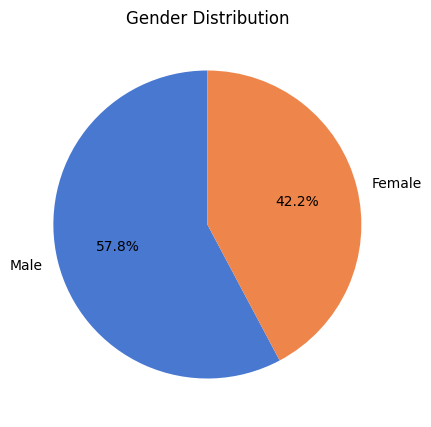

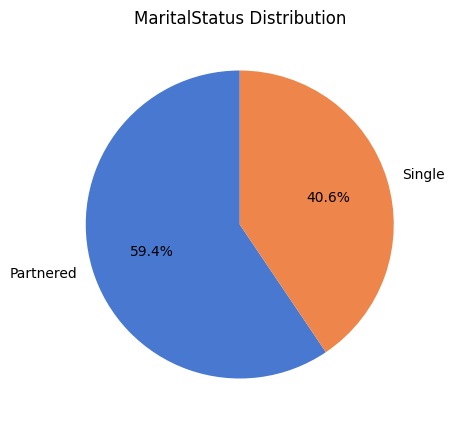

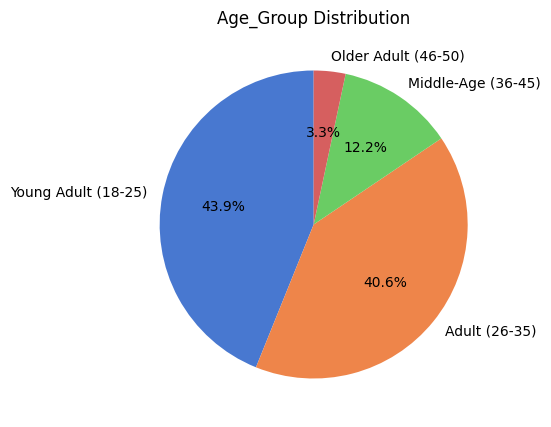

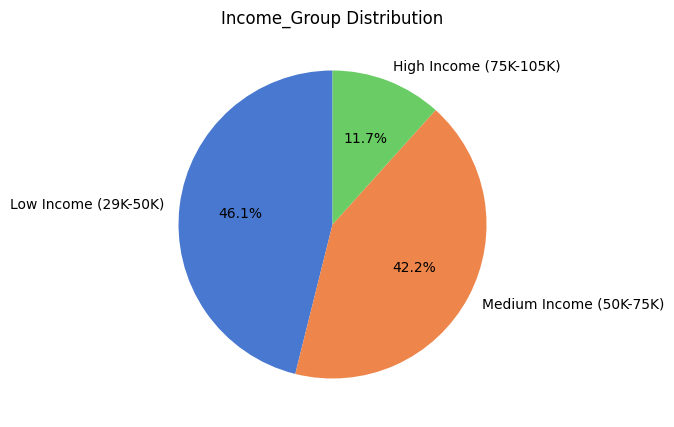

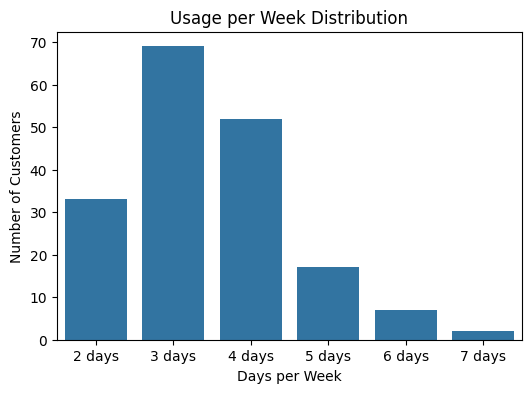

In [ ]:
# Pie Charts
pie_cols = ['Gender', 'MaritalStatus', 'Age_Group', 'Income_Group']

for col in pie_cols:
    plt.figure(figsize=(5,5))
    df[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('muted'))
    plt.title(f"{col} Distribution")
    plt.ylabel('')
    plt.show()

# Bar chart for usage_per_week
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='usage_per_week', order=df['usage_per_week'].cat.categories)
plt.title("Usage per Week Distribution")
plt.xlabel("Days per Week")
plt.ylabel("Number of Customers")
plt.show()

##### Univariate Analysis - Categorical Columns Quick Insights
Gender
*  Majority of customers are Male (104, 58%), while Females account for 42%.
*   Slightly higher male representation may influence product marketing strategies.

Marital Status
*   Most customers are Partnered (107, 61%), compared to Singles (73, 39%).
*   Suggests that treadmill purchases are more common among partnered individuals, possibly reflecting household investment in fitness.

Age Group
*   Young Adults (18–25) and Adults (26–35) make up the majority (79 and 73 respectively), covering ~80% of customers.
*   Middle-Age (36–45) and Older Adults (46–50) represent a smaller segment (~28%).
*   Indicates the core target audience is young to mid-aged adults.

Income Group
*   Majority fall into Low to Medium Income (159 out of 180 customers, ~88%).
*   Only a small fraction are High Income (21, 12%), suggesting most purchases come from middle-tier income customers.

Usage per Week
*   Most customers plan to use the treadmill 2–4 days per week (~154, 86%), with the peak at 3 days/week (69 customers).
*   Very few customers use the treadmill 6–7 days per week, indicating heavy users are a niche segment.
*   Suggests products should cater primarily to moderate, regular usage rather than extreme daily usage.










#### Numerical Columns


=== Univariate Analysis: Age ===

count    180.000000
mean      28.788889
std        6.943498
min       18.000000
25%       24.000000
50%       26.000000
75%       33.000000
max       50.000000
Name: Age, dtype: float64


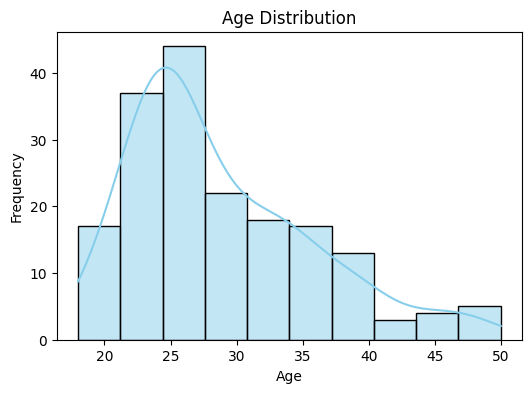

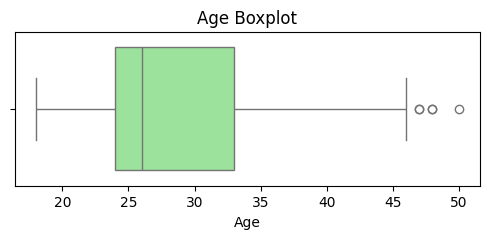

Skewness: 0.98, Kurtosis: 0.41


=== Univariate Analysis: Education ===

count    180.000000
mean      15.572222
std        1.617055
min       12.000000
25%       14.000000
50%       16.000000
75%       16.000000
max       21.000000
Name: Education, dtype: float64


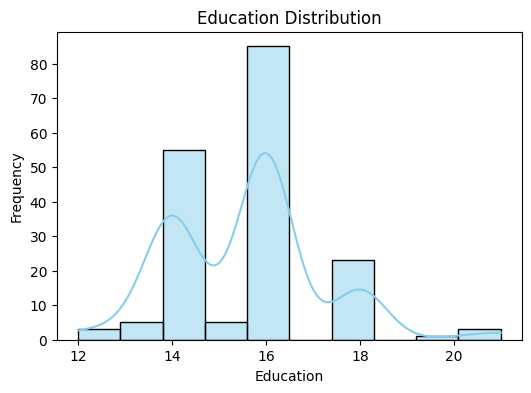

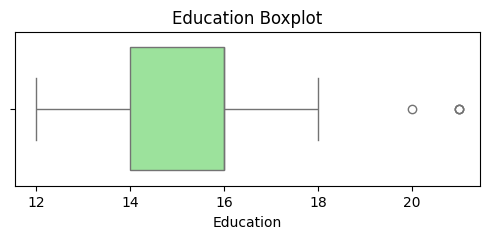

Skewness: 0.62, Kurtosis: 1.03


=== Univariate Analysis: Income ===

count       180.000000
mean      53719.577778
std       16506.684226
min       29562.000000
25%       44058.750000
50%       50596.500000
75%       58668.000000
max      104581.000000
Name: Income, dtype: float64


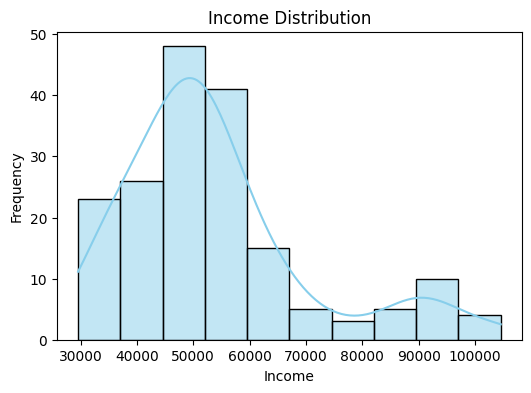

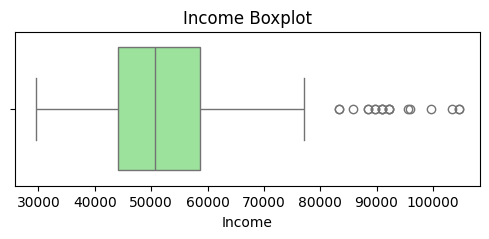

Skewness: 1.29, Kurtosis: 1.37


=== Univariate Analysis: Fitness ===

count    180.000000
mean       3.311111
std        0.958869
min        1.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: Fitness, dtype: float64


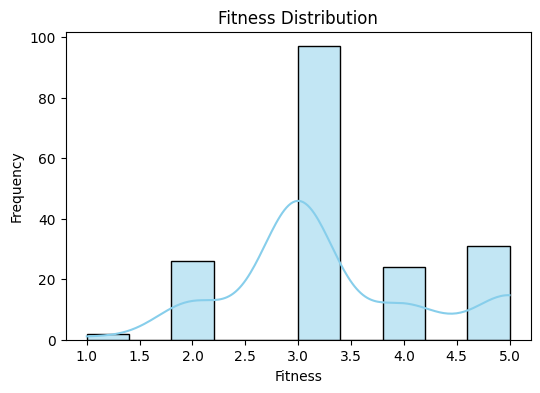

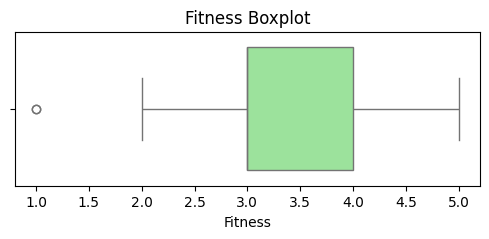

Skewness: 0.45, Kurtosis: -0.37


=== Univariate Analysis: Miles ===

count    180.000000
mean     103.194444
std       51.863605
min       21.000000
25%       66.000000
50%       94.000000
75%      114.750000
max      360.000000
Name: Miles, dtype: float64


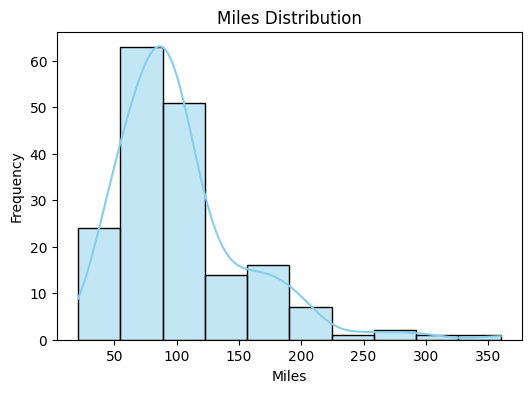

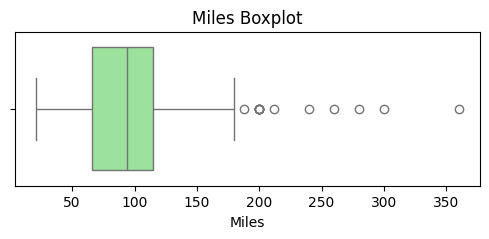

Skewness: 1.72, Kurtosis: 4.32



In [ ]:
numeric_cols = ['Age', 'Education', 'Income', 'Fitness', 'Miles']

for col in numeric_cols:
    print(f"\n=== Univariate Analysis: {col} ===\n")

    # Summary statistics
    summary = df[col].describe()
    print(summary)

    # Histogram
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=10, kde=True, color='skyblue', edgecolor='black')
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    # Boxplot
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f"{col} Boxplot")
    plt.show()

    # Skewness and Kurtosis
    print(f"Skewness: {df[col].skew():.2f}, Kurtosis: {df[col].kurt():.2f}\n")

##### Univariate Analysis - Numerical Columns Quick Insights

Age
*   Average age of customers is ~29 years, with a range from 18 to 50.
*   Skewness = 0.98 → moderately positively skewed; more younger customers.
*   Kurtosis = 0.41 → relatively flat distribution, indicating no extreme peaks.
*   Most customers fall between 24–33 years (25th–75th percentile), highlighting the core young adult to adult segment.

Education
*   Average education is ~15.6 years, mostly high school plus some college.
*   Skewness = 0.62 → slightly positively skewed, a few customers with higher education levels.
*   Kurtosis = 1.03 → distribution slightly peaked but fairly normal.
*   Suggests customers are generally well-educated, which may influence marketing messages emphasizing fitness knowledge.

Income
*   Average income is ~53,700, ranging from 29,562 to 104,581.
*   Skewness = 1.29 → positively skewed; most customers are in lower/middle-income range, few high-income outliers.
*   Kurtosis = 1.37 → slightly heavy-tailed; some customers with exceptionally high income.
*   25th–75th percentile (44,059–58,668) confirms majority of customers fall in low to medium income, aligning with univariate categorical analysis.

Fitness
*   Average fitness rating is 3.31/5, indicating moderate fitness.
*   Skewness = 0.45 → slight positive skew; few customers report lower fitness.
*   Kurtosis = -0.37 → slightly flat distribution; fitness ratings are spread across the scale.
*   Most customers rate themselves 3–4, suggesting products appeal to moderately active users.

Miles
*   Average weekly miles is ~103, with a large spread (21–360 miles).
*   Skewness = 1.72 → strongly positively skewed; a few customers run significantly more than most.
*   Kurtosis = 4.32 → leptokurtic; extreme values (high-mileage users) present.
*   25th–75th percentile (66–115 miles) indicates most customers run moderate distances, with high-mileage outliers forming a niche segment.

# Bivariate Analysis


### Two-way Contingency Tables & Visualization

#### Categorical Colums



=== Gender vs Product ===

Frequency Table:
 Gender   Female  Male  All
Product                   
KP281        40    40   80
KP481        29    31   60
KP781         7    33   40
All          76   104  180

Conditional Probability P(Gender|Product):
 Gender   Female  Male
Product              
KP281      0.50  0.50
KP481      0.48  0.52
KP781      0.18  0.82


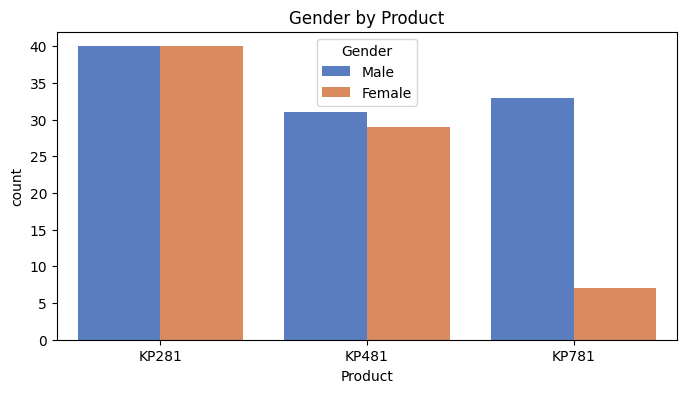


=== MaritalStatus vs Product ===

Frequency Table:
 MaritalStatus  Partnered  Single  All
Product                              
KP281                 48      32   80
KP481                 36      24   60
KP781                 23      17   40
All                  107      73  180

Conditional Probability P(MaritalStatus|Product):
 MaritalStatus  Partnered  Single
Product                         
KP281               0.60    0.40
KP481               0.60    0.40
KP781               0.57    0.42


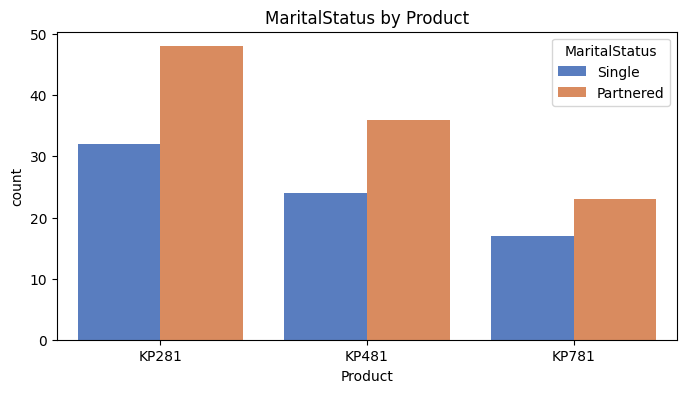


=== Age_Group vs Product ===

Frequency Table:
 Age_Group  Young Adult (18-25)  Adult (26-35)  Middle-Age (36-45)  \
Product                                                             
KP281                       34             32                  11   
KP481                       28             24                   7   
KP781                       17             17                   4   
All                         79             73                  22   

Age_Group  Older Adult (46-50)  All  
Product                              
KP281                        3   80  
KP481                        1   60  
KP781                        2   40  
All                          6  180  

Conditional Probability P(Age_Group|Product):
 Age_Group  Young Adult (18-25)  Adult (26-35)  Middle-Age (36-45)  \
Product                                                             
KP281                     0.42           0.40                0.14   
KP481                     0.47           0.40        

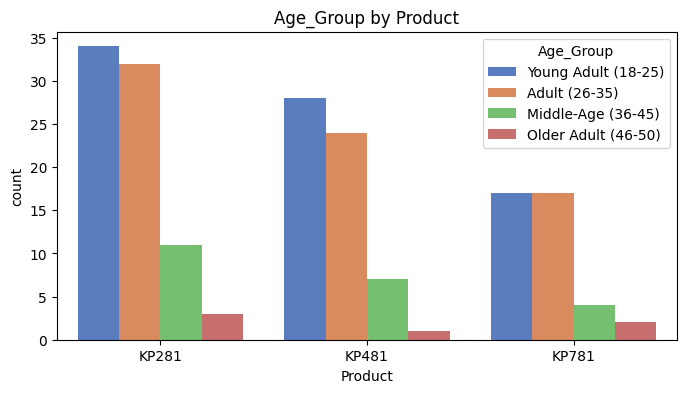


=== Income_Group vs Product ===

Frequency Table:
 Income_Group  Low Income (29K-50K)  Medium Income (50K-75K)  \
Product                                                       
KP281                           48                       32   
KP481                           30                       30   
KP781                            5                       14   
All                             83                       76   

Income_Group  High Income (75K-105K)  All  
Product                                    
KP281                              0   80  
KP481                              0   60  
KP781                             21   40  
All                               21  180  

Conditional Probability P(Income_Group|Product):
 Income_Group  Low Income (29K-50K)  Medium Income (50K-75K)  \
Product                                                       
KP281                         0.60                     0.40   
KP481                         0.50                     0.50   
KP

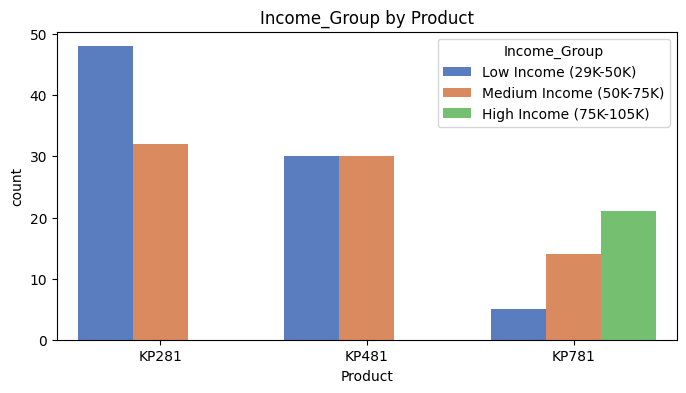


=== usage_per_week vs Product ===

Frequency Table:
 usage_per_week  2 days  3 days  4 days  5 days  6 days  7 days  All
Product                                                            
KP281               19      37      22       2       0       0   80
KP481               14      31      12       3       0       0   60
KP781                0       1      18      12       7       2   40
All                 33      69      52      17       7       2  180

Conditional Probability P(usage_per_week|Product):
 usage_per_week  2 days  3 days  4 days  5 days  6 days  7 days
Product                                                       
KP281             0.24    0.46    0.28    0.02    0.00    0.00
KP481             0.23    0.52    0.20    0.05    0.00    0.00
KP781             0.00    0.02    0.45    0.30    0.18    0.05


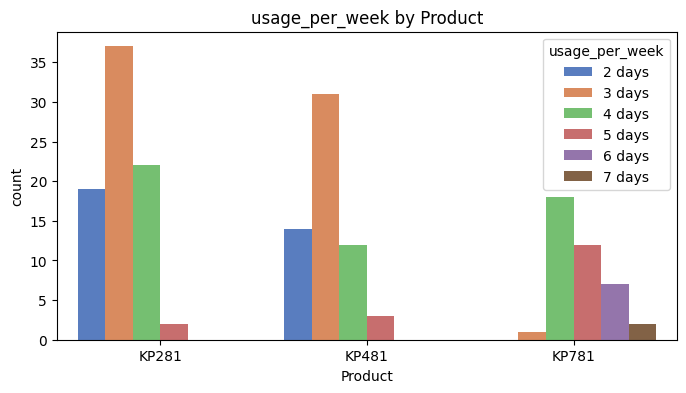

In [ ]:
# List of categorical and numerical columns
categorical_cols = ['Gender', 'MaritalStatus', 'Age_Group', 'Income_Group', 'usage_per_week']
numeric_cols = ['Age', 'Income', 'Fitness', 'Miles']

# Categorical vs Product
for col in categorical_cols:
    print(f"\n=== {col} vs Product ===\n")

    # Frequency table (two-way contingency table)
    freq_table = pd.crosstab(df['Product'], df[col], margins=True)
    print("Frequency Table:\n", freq_table)

    # Conditional probability (P(col|Product))
    cond_prob = pd.crosstab(df['Product'], df[col], normalize='index')
    print("\nConditional Probability P({}|Product):\n".format(col), cond_prob.round(2))

    # Barplot
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x='Product', hue=col, palette='muted')
    plt.title(f"{col} by Product")
    plt.show()



##### Bivariate Analysis - Categorical Columns Quick Insights

Gender vs Product
* KP281: Balanced gender distribution (50% Male, 50% Female).
* KP481: Slightly more males (52%) than females (48%).
* KP781: Majority male (82%), only 18% female.
Business Insight:
* Entry-level KP281 appeals equally to both genders.
* Premium KP781 is predominantly purchased by males → marketing campaigns for KP781 could target male users more effectively.

Marital Status vs Product
* KP281 & KP481: 60% partnered, 40% single.
* KP781: Slightly lower proportion partnered (57%), 42% single.
Business Insight:
* Most treadmill purchases are by partnered individuals across all products.
* Suggests campaigns emphasizing family/household fitness may resonate with the majority of users.

Age Group vs Product
* KP281: Mostly young adults (42%) and adults (40%).
* KP481: Young adults slightly higher (47%), adults 40%.
* KP781: Equal proportion of young adults and adults (42%), fewer middle-aged (10%), and some older adults (5%).
Business Insight:
* All products target primarily 18–35 years, with KP281 slightly skewed younger.
* KP781 has slightly more adult users (26–35) compared to entry-level KP281 → product appeal shifts toward more established, active customers.

Income Group vs Product
* KP281: 60% low income, 40% medium income, 0% high income.
* KP481: Balanced between low (50%) and medium (50%), 0% high income.
* KP781: Majority high income (52%), some medium (35%), few low income (12%).
Business Insight:
* Entry-level and mid-level treadmills appeal to low-to-middle income groups.
* Premium KP781 is clearly purchased by high-income customers, aligning product tiers with income levels.
* Marketing messages can be tier-specific: affordability focus for KP281, premium features for KP781.

Usage per Week vs Product
* KP281: 24% use 2 days/week, 46% use 3 days/week, 28% use 4 days/week, 2% use 5 days/week, 0% use 6–7 days/week.
* KP481: 23% use 2 days/week, 52% use 3 days/week, 20% use 4 days/week, 5% use 5 days/week, 0% use 6–7 days/week.
* KP781: 0% use 2 days/week, 2% use 3 days/week, 45% use 4 days/week, 30% use 5 days/week, 18% use 6 days/week, 5% use 7 days/week.
Business Insight:
* Usage frequency aligns with product tiers: KP281 and KP481 appeal to casual/moderate users, while KP781 attracts high-frequency, dedicated users.
* Marketing can be tier-specific: convenience and accessibility for entry-level products, advanced performance and commitment for premium products.
* Usage patterns can guide personalized product recommendations for new customers based on expected weekly treadmill usage.

#### Numerical Columns


=== Age by Product ===



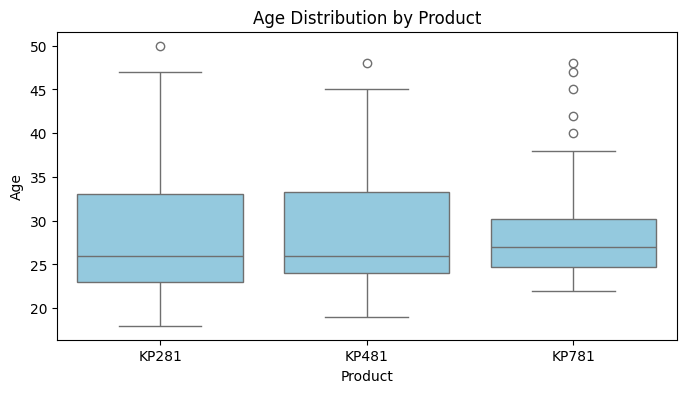

          mean  median  min  max
Product                         
KP281    28.55    26.0   18   50
KP481    28.90    26.0   19   48
KP781    29.10    27.0   22   48

=== Income by Product ===



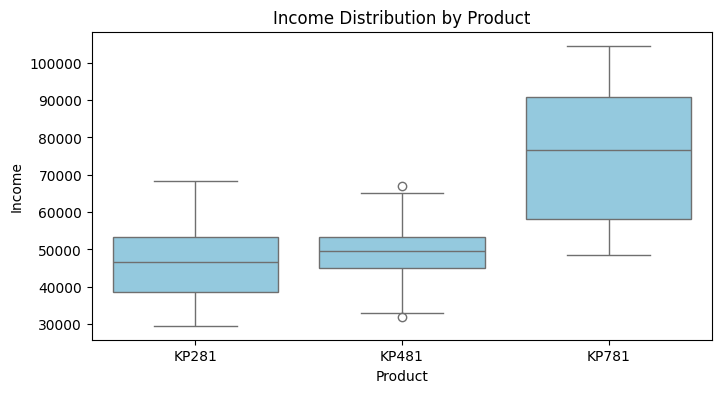

              mean   median    min     max
Product                                   
KP281    46418.025  46617.0  29562   68220
KP481    48973.650  49459.5  31836   67083
KP781    75441.575  76568.5  48556  104581

=== Fitness by Product ===



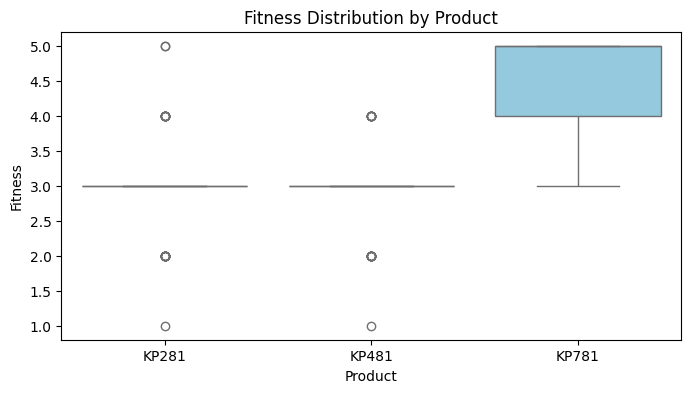

           mean  median  min  max
Product                          
KP281    2.9625     3.0    1    5
KP481    2.9000     3.0    1    4
KP781    4.6250     5.0    3    5

=== Miles by Product ===



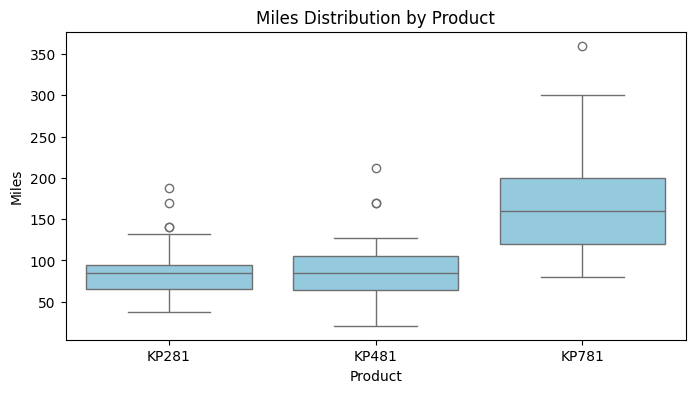

               mean  median  min  max
Product                              
KP281     82.787500    85.0   38  188
KP481     87.933333    85.0   21  212
KP781    166.900000   160.0   80  360


In [ ]:
# Numerical vs Product
for col in numeric_cols:
    print(f"\n=== {col} by Product ===\n")

    # Boxplot
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x='Product', y=col, color='skyblue')
    plt.title(f"{col} Distribution by Product")
    plt.show()

    # Summary stats
    summary = df.groupby('Product')[col].agg(['mean','median','min','max'])
    print(summary)


##### Bivariate Analysis - Numerical Columns Quick Insights
Age by Product
* KP281: mean 28.55, median 26, range 18–50
* KP481: mean 28.9, median 26, range 19–48
* KP781: mean 29.1, median 27, range 22–48
Insights:
* Age distribution is similar across products (core 26–29 years).
* KP781 slightly older on average, indicating premium users tend to be slightly more mature.
* Moderate variability across all products (range ~30 years).

Income by Product
* KP281: mean ~$46k, median ~$46k, range 29.5–68k
* KP481: mean ~$49k, median ~$49k, range 31.8–67k
* KP781: mean ~$75k, median ~$76k, range 48.5–104k
Insights:
* Clear income tier separation: KP781 is high-income users, KP281/KP481 are low-to-middle income.
* KP781 has much wider spread → some very high-income outliers.
* Boxplot comparison highlights product tier alignment with income.

Fitness by Product
* KP281: mean ~2.96, median 3, range 1–5
* KP481: mean ~2.9, median 3, range 1–4
* KP781: mean ~4.63, median 5, range 3–5
Insights:
* KP781 users are significantly fitter than KP281/KP481 users.
* Median and mean differences indicate KP781 is right-shifted (higher fitness), confirming premium product attracts highly fit users.
* Low variability in KP781 (box smaller, high median) → consistently fit user segment.

Miles by Product
* KP281: mean ~83, median 85, range 38–188
* KP481: mean ~88, median 85, range 21–212
* KP781: mean ~167, median 160, range 80–360
Insights:
* KP781 users run much more miles than KP281/KP481 → heavy users cluster here.
* Larger range and higher median in KP781 → consistent with premium, highly active users.
* KP281/KP481 users have similar usage patterns (moderate miles), showing entry- and mid-level products target casual/moderate users.

Business Implications
* Premium KP781 targets high-income, highly fit, heavy users, slightly older than entry-level users.
* KP281 and KP481 appeal to moderate-income, moderately active users.

# Correlation Analysis and Customer Profiling

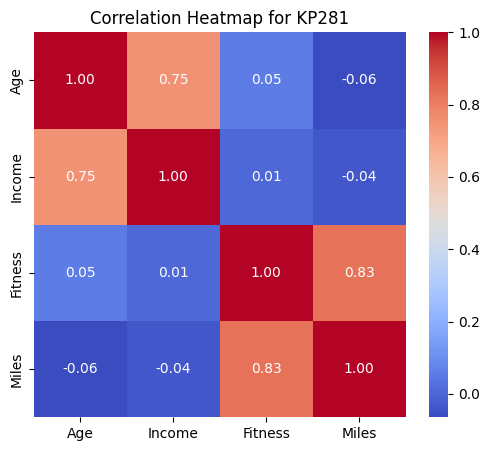

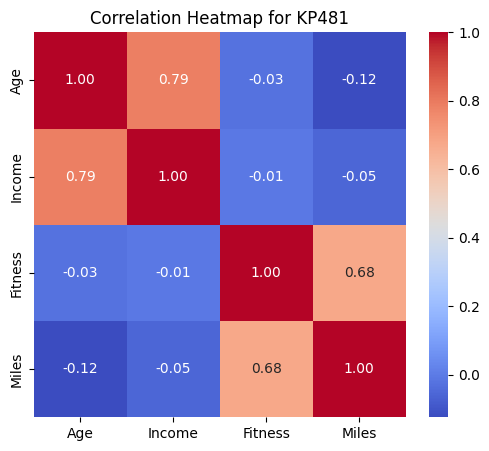

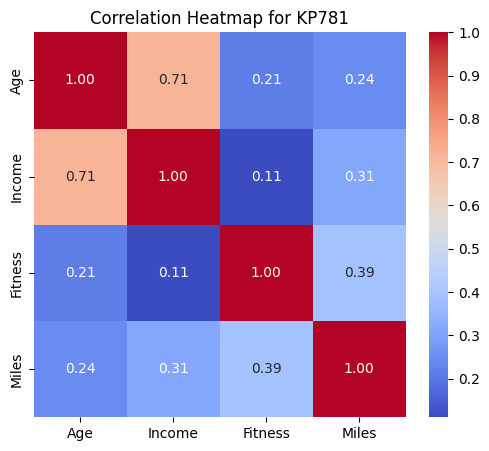

In [ ]:
numeric_cols = ['Age','Income','Fitness','Miles']


for product in df['Product'].unique():
    df_product = df[df['Product'] == product]

    plt.figure(figsize=(6,5))
    corr = df_product[numeric_cols].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f"Correlation Heatmap for {product}")
    plt.show()


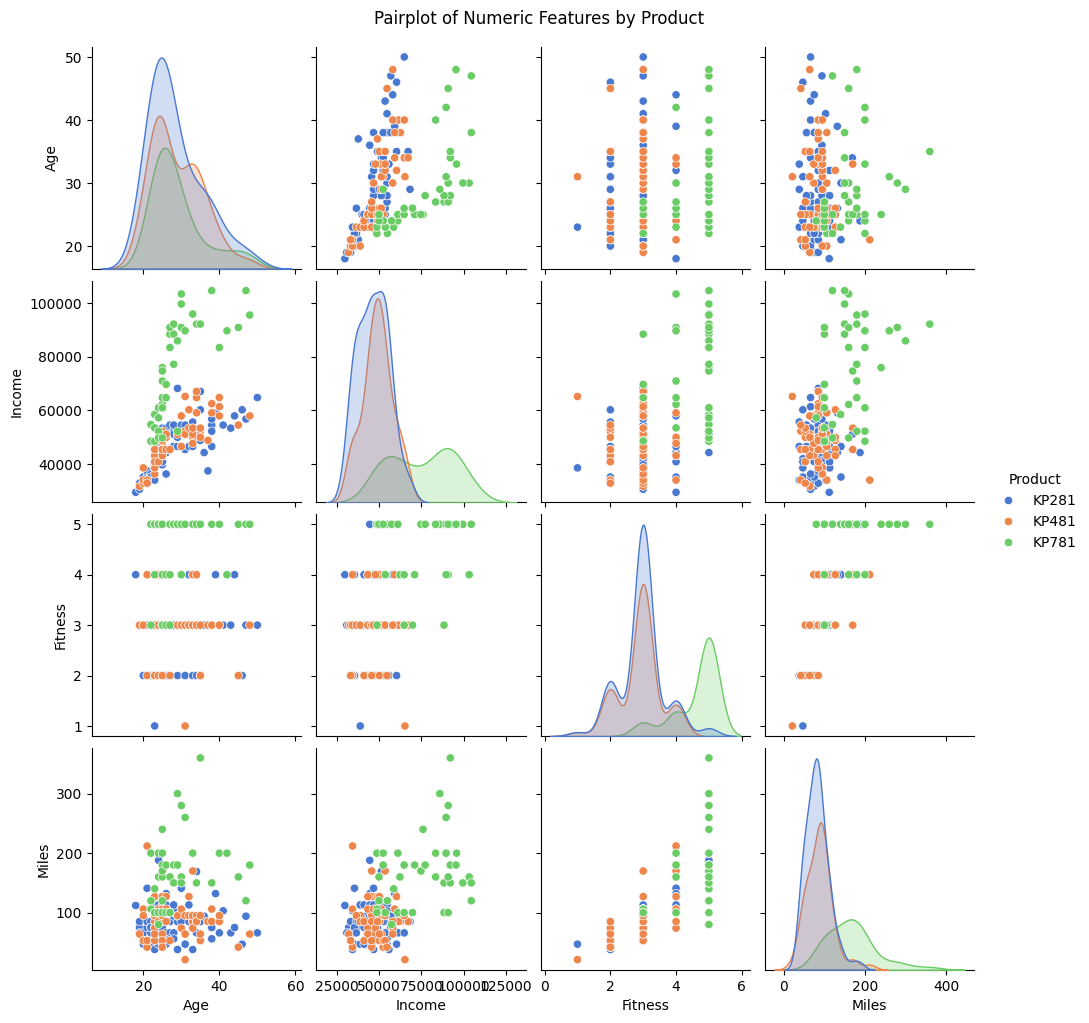

In [ ]:
sns.pairplot(df,
             vars=numeric_cols,
             hue='Product',
             palette='muted',
             diag_kind='kde',  # smooth distribution on diagonal
             corner=False)     # shows all combinations
plt.suptitle("Pairplot of Numeric Features by Product", y=1.02)
plt.show()


#### Correlation Analysis Quick Insights
Age vs Other Variables
Age vs Income:
* Slight upward trend: older customers tend to earn a bit more, but the effect is moderate.
Age vs Miles/Usage:
* Younger users are scattered across low-to-moderate miles and usage.
* No strong linear trend; age is less determinant of treadmill usage compared to fitness or product type.

Income vs Other Variables
Income vs Miles:
* KP781 (green) cluster shows high-income, high-mileage users, clearly separated from KP281/KP481.
Income vs Fitness:
* KP781 users are fitter, confirming premium product targets health-conscious, high-income segment.
* Insight: Income strongly aligns with product type and engagement level.

Fitness vs Miles
* Strong positive association across products: fitter users cover more miles.
* KP781 users are distinctly clustered in high fitness, high miles, reinforcing product differentiation.

Product Clustering
* KP281 (blue): Moderate income, moderate fitness, lower miles.
* KP481 (orange): Slightly higher income than KP281, moderate fitness, moderate miles.
* KP781 (green): High income, very fit, heavy mileage users.

Heatmap Insights
* Miles vs Usage: Strong positive correlation - high-frequency users run more miles.
* Fitness vs Miles: Positive correlation - fitter users engage more in activity.
* Income vs Miles/Fitness: Moderate positive correlation - high-income users tend to be fitter and more active.
* Age correlations: Weak correlations with most variables - age is less predictive than income or fitness for product segmentation.

Business Insights
* Miles and Usage: engagement
* Fitness: readiness for premium product
* Income: purchasing power

#### Customer Profiling for Each Product
1. KP281 – Entry-Level Treadmill

Price: $1,500

Demographics:
* Gender: Balanced (50% Male, 50% Female) → appeals equally to both genders.
* Marital Status: Mostly partnered (60%), 40% single → suitable for household/family-oriented campaigns.
* Age Group: Primarily young adults (42%) and adults (40%), mean age ~28.5 → slightly skewed toward younger users.
* Income Group: 60% low income, 40% medium income → budget-conscious, affordability-focused segment.

Behavior & Usage:
* Usage Frequency: Casual/moderate users (2–4 days/week; median 3 days).
* Fitness Level: Moderate fitness (mean ~3/5).
* Miles Run: Moderate mileage (mean ~83 miles).

Insights / Marketing Persona:
* Entry-level, price-sensitive customers who want basic treadmill functionality for casual home fitness.
* Likely to be younger, partnered individuals starting or maintaining a fitness routine.

Marketing message: affordability, convenience, simple features, and family/household fitness appeal.

2. KP481 – Mid-Level Treadmill

Price: $1,750

Demographics:
* Gender: Slightly more males (52%) than females (48%).
* Marital Status: Mostly partnered (60%).
* Age Group: Young adults (47%), adults (40%), mean age ~28.9 → similar to KP281, slightly more male.
* Income Group: Balanced between low and medium income (50% each) → middle-income aspirational buyers.

Behavior & Usage:
* Usage Frequency: Moderate users (2–5 days/week; median 3 days).
* Fitness Level: Moderate fitness (mean ~2.9/5).
* Miles Run: Moderate mileage (mean ~88 miles).

Insights / Marketing Persona:
* Customers seeking a step-up from basic treadmills—slightly more serious about fitness but not extreme athletes.
* Likely to value durability, a few advanced features, and moderate performance.

Marketing message: reliable mid-tier product for regular home workouts, bridging affordability and performance.

3. KP781 – Premium Treadmill

Price: $2,500

Demographics:
* Gender: Predominantly male (82%), 18% female → campaigns can target male users more.
* Marital Status: 57% partnered, 42% single → appeals to both individual and household buyers.
* Age Group: Equal proportion of young adults and adults (42%), fewer middle-aged (10%), mean age ~29.1 → slightly older than entry-level buyers.
* Income Group: Majority high income (52%), some medium (35%), few low income (12%) → high purchasing power segment.

Behavior & Usage:
* Usage Frequency: Heavy, committed users (4–7 days/week; median 5 days).
* Fitness Level: Very fit (mean ~4.63/5) → consistently fit, high-performing users.
* Miles Run: High mileage (mean ~167 miles) → premium product attracts serious runners.

Insights / Marketing Persona:
* Premium, high-income, highly fit users with a strong commitment to fitness.
* Likely to use the treadmill intensively, value advanced features, and expect high performance.

Marketing message: elite performance, advanced technology, heavy usage capability, and fitness optimization.

# Customer Profiling per Product -  Summary Table
| Product | Price   | Gender  | Age Group | Income     | Fitness  | Usage (days/week) | Miles | Customer Persona                                                 |
| ------- | ------- | ------- | --------- | ---------- | -------- | ----------------- | ----- | ---------------------------------------------------------------- |
| KP281   | \$1,500 | 50M/50F | 18–29     | Low/Medium | Moderate | 2–4               | 83    | Casual, younger, budget-conscious, household fitness starter     |
| KP481   | \$1,750 | 52M/48F | 19–29     | Low/Medium | Moderate | 2–5               | 88    | Regular, moderately serious, value-conscious fitness enthusiasts |
| KP781   | \$2,500 | 82M/18F | 22–35     | High       | Very Fit | 4–7               | 167   | Dedicated, high-income, performance-driven, elite fitness users  |


In [ ]:
# Convert python notebook to html, which is then saved as pdf so that all scrollable graphs are included in the pdf file
!jupyter nbconvert --to html /content/AerofitCaseStudy.ipynb


[NbConvertApp] Converting notebook /content/AerofitCaseStudy.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 28 image(s).
[NbConvertApp] Writing 1415840 bytes to /content/AerofitCaseStudy.html
